<a href="https://colab.research.google.com/github/codewithzainab121/MLproj-ds/blob/main/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name:** Zainab Farukh  
**Instructor:** Abdullah Khan  
**Date:** 25 March, 2026

# Customer Segmentation Project Report
In this project, we analyze a dataset containing the following features:
- **CustomerID** – Unique identifier for each customer
- **Gender** – Male or Female
- **Profession** – Job category of the customer
- **Spending Score** – Score representing spending habits
- **Age** – Age of the customer

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler

## 1. Data Exploration

In [2]:
df = pd.read_csv('Train.csv')
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [3]:
df.shape

(8068, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [5]:
df.describe()

,ID,Age,Work_Experience,Family_Size
count,8068.000000,8068.000000,7239.000000,7733.000000
mean,463479.214551,43.466906,2.641663,2.850123
std,2595.381232,16.711696,3.406763,1.531413
min,458982.000000,18.000000,0.000000,1.000000
25%,461240.750000,30.000000,0.000000,2.000000
50%,463472.500000,40.000000,1.000000,3.000000
75%,465744.250000,53.000000,4.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


In [6]:
df.duplicated().sum()

np.int64(0)

## 2. Handling Missing Data

Missing values can distort analysis, so we handle them carefully:
- Identify columns with missing values
- Replace missing categorical values with the most frequent category (mode)
- Replace missing numerical values with the median

In [7]:
df.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,140
Age,0
Graduated,78
Profession,124
Work_Experience,829
Spending_Score,0
Family_Size,335
Var_1,76


In [8]:
df['Ever_Married'].fillna(df['Ever_Married'].mode()[0], inplace=True)
df['Graduated'].fillna(df['Graduated'].mode()[0], inplace=True)
df['Profession'].fillna(df['Profession'].mode()[0], inplace=True)
df['Spending_Score'].fillna(df['Spending_Score'].mode()[0], inplace=True)
df['Var_1'].fillna(df['Var_1'].mode()[0], inplace=True)
df['Segmentation'].fillna(df['Segmentation'].mode()[0], inplace=True)

df['Age'].fillna(df['Age'].median(), inplace=True)
df['Work_Experience'].fillna(df['Work_Experience'].median(), inplace=True)
df['Family_Size'].fillna(df['Family_Size'].median(), inplace=True)

df.isnull().sum()

/tmp/ipykernel_4623/1282699682.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Ever_Married'].fillna(df['Ever_Married'].mode()[0], inplace=True)
/tmp/ipykernel_4623/1282699682.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

,0
ID,0
Gender,0
Ever_Married,0
Age,0
Graduated,0
Profession,0
Work_Experience,0
Spending_Score,0
Family_Size,0
Var_1,0


In [9]:
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,1.0,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,1.0,High,6.0,Cat_6,A


## 3. Outlier Detection

### IQR Method

In [10]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers = df[(df['Age'] < lower_fence) | (df['Age'] > upper_fence)]
print("Age outliers:", len(outliers))

Age outliers: 71


In [11]:
Q1 = df['Work_Experience'].quantile(0.25)
Q3 = df['Work_Experience'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers = df[(df['Work_Experience'] < lower_fence) | (df['Work_Experience'] > upper_fence)]
print("Work_Experience outliers:", len(outliers))

Work_Experience outliers: 189


In [12]:
Q1 = df['Family_Size'].quantile(0.25)
Q3 = df['Family_Size'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers = df[(df['Family_Size'] < lower_fence) | (df['Family_Size'] > upper_fence)]
print("Family_Size outliers:", len(outliers))

Family_Size outliers: 94


### Boxplot Technique for Outlier Detection

* A boxplot (or "box-and-whisker plot") is a visual tool to detect outliers. It uses the IQR method but presents it graphically, making it easy to spot anomalies.

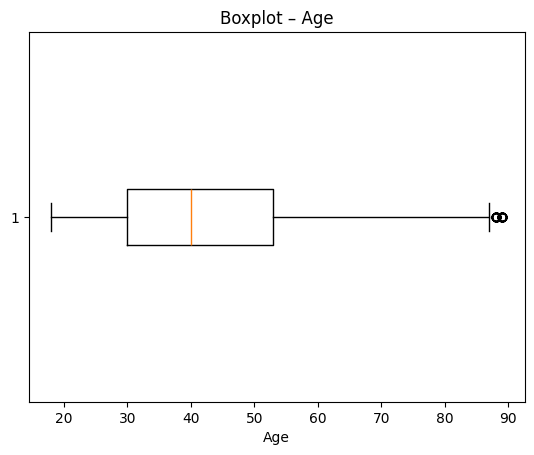

In [13]:
plt.boxplot(df['Age'], vert=False)
plt.title("Boxplot – Age")
plt.xlabel("Age")
plt.show()

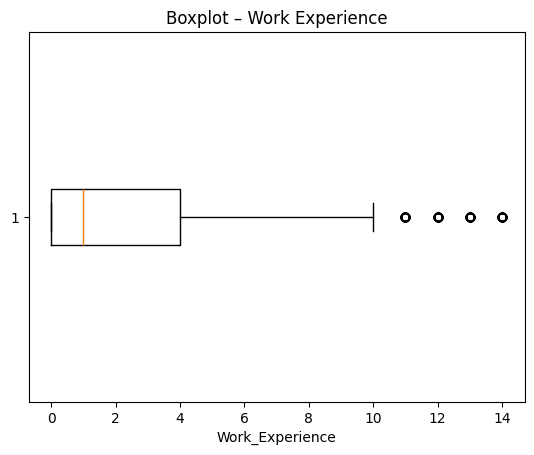

In [14]:
plt.boxplot(df['Work_Experience'], vert=False)
plt.title("Boxplot – Work Experience")
plt.xlabel("Work_Experience")
plt.show()

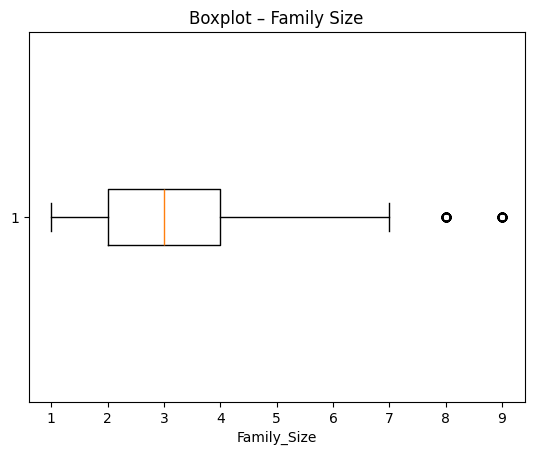

In [15]:
plt.boxplot(df['Family_Size'], vert=False)
plt.title("Boxplot – Family Size")
plt.xlabel("Family_Size")
plt.show()

## 4. Outlier Treatment

### Cap Outliers (Winsorization)

After identifying outliers we cap them to the IQR fences. This preserves all rows while limiting the effect of extreme values.

In [16]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Age'] = df['Age'].clip(lower=lower, upper=upper)
print("Age  ->  min:", df['Age'].min(), "  max:", df['Age'].max())

Age  ->  min: 18.0   max: 87.5


In [17]:
Q1 = df['Work_Experience'].quantile(0.25)
Q3 = df['Work_Experience'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Work_Experience'] = df['Work_Experience'].clip(lower=lower, upper=upper)
print("Work_Experience  ->  min:", df['Work_Experience'].min(), "  max:", df['Work_Experience'].max())

Work_Experience  ->  min: 0.0   max: 10.0


In [18]:
Q1 = df['Family_Size'].quantile(0.25)
Q3 = df['Family_Size'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Family_Size'] = df['Family_Size'].clip(lower=lower, upper=upper)
print("Family_Size  ->  min:", df['Family_Size'].min(), "  max:", df['Family_Size'].max())

Family_Size  ->  min: 1.0   max: 7.0


In [19]:
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22.0,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38.0,Yes,Engineer,1.0,Average,3.0,Cat_4,A
2,466315,Female,Yes,67.0,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67.0,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40.0,Yes,Entertainment,1.0,High,6.0,Cat_6,A


## 5. Encoding Categorical Variables

Machine learning algorithms require numerical input:
- Binary columns (Gender, Ever_Married, Graduated) -> **Label Encoding**
- Ordinal column (Spending_Score: Low / Average / High) -> **Manual mapping** to preserve order
- Multi-category columns (Profession, Var_1) -> **One-Hot Encoding**
- Target column (Segmentation) -> **Label Encoding**

In [20]:
label_encoder = LabelEncoder()

df['Gender'] = label_encoder.fit_transform(df['Gender'])
df['Ever_Married'] = label_encoder.fit_transform(df['Ever_Married'])
df['Graduated'] = label_encoder.fit_transform(df['Graduated'])
df['Segmentation'] = label_encoder.fit_transform(df['Segmentation'])

df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,1,0,22.0,0,Healthcare,1.0,Low,4.0,Cat_4,3
1,462643,0,1,38.0,1,Engineer,1.0,Average,3.0,Cat_4,0
2,466315,0,1,67.0,1,Engineer,1.0,Low,1.0,Cat_6,1
3,461735,1,1,67.0,1,Lawyer,0.0,High,2.0,Cat_6,1
4,462669,0,1,40.0,1,Entertainment,1.0,High,6.0,Cat_6,0


In [21]:
spending_order = {'Low': 0, 'Average': 1, 'High': 2}
df['Spending_Score'] = df['Spending_Score'].map(spending_order)

df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,1,0,22.0,0,Healthcare,1.0,0,4.0,Cat_4,3
1,462643,0,1,38.0,1,Engineer,1.0,1,3.0,Cat_4,0
2,466315,0,1,67.0,1,Engineer,1.0,0,1.0,Cat_6,1
3,461735,1,1,67.0,1,Lawyer,0.0,2,2.0,Cat_6,1
4,462669,0,1,40.0,1,Entertainment,1.0,2,6.0,Cat_6,0


In [22]:
df = pd.get_dummies(df, columns=['Profession', 'Var_1'], drop_first=True, dtype=int)

df.head()

,ID,Gender,Ever_Married,Age,Graduated,Work_Experience,Spending_Score,Family_Size,Segmentation,Profession_Doctor,...,Profession_Healthcare,Profession_Homemaker,Profession_Lawyer,Profession_Marketing,Var_1_Cat_2,Var_1_Cat_3,Var_1_Cat_4,Var_1_Cat_5,Var_1_Cat_6,Var_1_Cat_7
0,462809,1,0,22.0,0,1.0,0,4.0,3,0,...,1,0,0,0,0,0,1,0,0,0
1,462643,0,1,38.0,1,1.0,1,3.0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,466315,0,1,67.0,1,1.0,0,1.0,1,0,...,0,0,0,0,0,0,0,0,1,0
3,461735,1,1,67.0,1,0.0,2,2.0,1,0,...,0,0,1,0,0,0,0,0,1,0
4,462669,0,1,40.0,1,1.0,2,6.0,0,0,...,0,0,0,0,0,0,0,0,1,0


## 6. Feature Engineering

- **AgeGroup** – Categorize ages as Young (0), Middle-aged (1), or Senior (2)
- **HighSpender** – Flag customers with a High Spending Score (1 = High, 0 = otherwise)

In [23]:
def age_group(age):
    if age < 30:
        return 0
    elif age < 55:
        return 1
    else:
        return 2

df['AgeGroup'] = df['Age'].apply(age_group)
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Work_Experience,Spending_Score,Family_Size,Segmentation,Profession_Doctor,...,Profession_Homemaker,Profession_Lawyer,Profession_Marketing,Var_1_Cat_2,Var_1_Cat_3,Var_1_Cat_4,Var_1_Cat_5,Var_1_Cat_6,Var_1_Cat_7,AgeGroup
0,462809,1,0,22.0,0,1.0,0,4.0,3,0,...,0,0,0,0,0,1,0,0,0,0
1,462643,0,1,38.0,1,1.0,1,3.0,0,0,...,0,0,0,0,0,1,0,0,0,1
2,466315,0,1,67.0,1,1.0,0,1.0,1,0,...,0,0,0,0,0,0,0,1,0,2
3,461735,1,1,67.0,1,0.0,2,2.0,1,0,...,0,1,0,0,0,0,0,1,0,2
4,462669,0,1,40.0,1,1.0,2,6.0,0,0,...,0,0,0,0,0,0,0,1,0,1


In [24]:
df['HighSpender'] = (df['Spending_Score'] == 2).astype(int)
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Work_Experience,Spending_Score,Family_Size,Segmentation,Profession_Doctor,...,Profession_Lawyer,Profession_Marketing,Var_1_Cat_2,Var_1_Cat_3,Var_1_Cat_4,Var_1_Cat_5,Var_1_Cat_6,Var_1_Cat_7,AgeGroup,HighSpender
0,462809,1,0,22.0,0,1.0,0,4.0,3,0,...,0,0,0,0,1,0,0,0,0,0
1,462643,0,1,38.0,1,1.0,1,3.0,0,0,...,0,0,0,0,1,0,0,0,1,0
2,466315,0,1,67.0,1,1.0,0,1.0,1,0,...,0,0,0,0,0,0,1,0,2,0
3,461735,1,1,67.0,1,0.0,2,2.0,1,0,...,1,0,0,0,0,0,1,0,2,1
4,462669,0,1,40.0,1,1.0,2,6.0,0,0,...,0,0,0,0,0,0,1,0,1,1


## 7. Feature Scaling

- **Normalize** features to scale values between 0 and 1
- **Standardize** features to have a mean of 0 and SD of 1

In [25]:
scale_cols = ['Age', 'Work_Experience', 'Family_Size']

mm = MinMaxScaler()
df_normalized = df.copy()
df_normalized[scale_cols] = mm.fit_transform(df[scale_cols])

print("After Min-Max Normalization:")
df_normalized[scale_cols].head()

After Min-Max Normalization:


,Age,Work_Experience,Family_Size
0,0.057554,0.1,0.500000
1,0.287770,0.1,0.333333
2,0.705036,0.1,0.000000
3,0.705036,0.0,0.166667
4,0.316547,0.1,0.833333


In [26]:
ss = StandardScaler()
df[scale_cols] = ss.fit_transform(df[scale_cols])

print("After Standardization (mean=0, SD=1):")
df[scale_cols].describe().round(3)

After Standardization (mean=0, SD=1):


,Age,Work_Experience,Family_Size
count,8068.000,8068.000,8068.000
mean,-0.000,0.000,-0.000
std,1.000,1.000,1.000
min,-1.526,-0.779,-1.276
25%,-0.807,-0.779,-0.582
50%,-0.207,-0.456,0.112
75%,0.572,0.511,0.805
max,2.639,2.445,2.886


In [27]:
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Work_Experience,Spending_Score,Family_Size,Segmentation,Profession_Doctor,...,Profession_Lawyer,Profession_Marketing,Var_1_Cat_2,Var_1_Cat_3,Var_1_Cat_4,Var_1_Cat_5,Var_1_Cat_6,Var_1_Cat_7,AgeGroup,HighSpender
0,462809,1,0,-1.285917,0,-0.456344,0,0.805152,3,0,...,0,0,0,0,1,0,0,0,0,0
1,462643,0,1,-0.327084,1,-0.456344,1,0.111509,0,0,...,0,0,0,0,1,0,0,0,1,0
2,466315,0,1,1.410800,1,-0.456344,0,-1.275777,1,0,...,0,0,0,0,0,0,1,0,2,0
3,461735,1,1,1.410800,1,-0.778742,2,-0.582134,1,0,...,1,0,0,0,0,0,1,0,2,1
4,462669,0,1,-0.207230,1,-0.456344,2,2.192437,0,0,...,0,0,0,0,0,0,1,0,1,1


## 8. Exploratory Data Analysis (EDA)


In [28]:
raw = pd.read_csv('Train.csv')
raw['Age'].fillna(raw['Age'].median(), inplace=True)
raw['Work_Experience'].fillna(raw['Work_Experience'].median(), inplace=True)
raw['Family_Size'].fillna(raw['Family_Size'].median(), inplace=True)
raw['Profession'].fillna(raw['Profession'].mode()[0], inplace=True)
raw['Spending_Score'].fillna(raw['Spending_Score'].mode()[0], inplace=True)

/tmp/ipykernel_4623/146845681.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  raw['Age'].fillna(raw['Age'].median(), inplace=True)
/tmp/ipykernel_4623/146845681.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

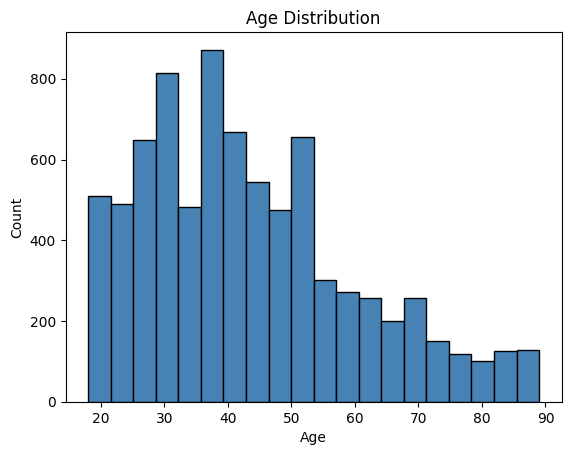

In [29]:
plt.hist(raw['Age'], bins=20, color='steelblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

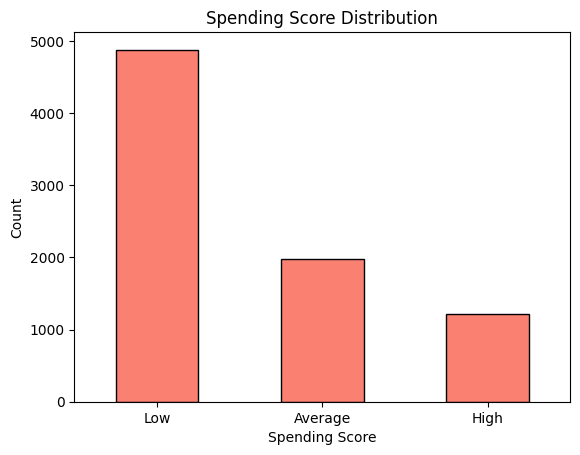

In [30]:
raw['Spending_Score'].value_counts().reindex(['Low', 'Average', 'High']).plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Spending Score Distribution')
plt.xlabel('Spending Score')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

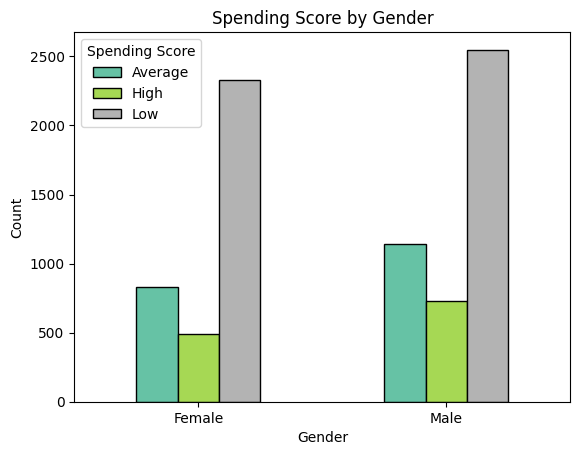

In [31]:
raw.groupby(['Gender', 'Spending_Score']).size().unstack(fill_value=0).plot(kind='bar', colormap='Set2', edgecolor='black')
plt.title('Spending Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Spending Score')
plt.show()

## 9. Final Clean Dataset

In [32]:
print("Final dataset shape:", df.shape)
df.head(10)

Final dataset shape: (8068, 25)


,ID,Gender,Ever_Married,Age,Graduated,Work_Experience,Spending_Score,Family_Size,Segmentation,Profession_Doctor,...,Profession_Lawyer,Profession_Marketing,Var_1_Cat_2,Var_1_Cat_3,Var_1_Cat_4,Var_1_Cat_5,Var_1_Cat_6,Var_1_Cat_7,AgeGroup,HighSpender
0,462809,1,0,-1.285917,0,-0.456344,0,0.805152,3,0,...,0,0,0,0,1,0,0,0,0,0
1,462643,0,1,-0.327084,1,-0.456344,1,0.111509,0,0,...,0,0,0,0,1,0,0,0,1,0
2,466315,0,1,1.410800,1,-0.456344,0,-1.275777,1,0,...,0,0,0,0,0,0,1,0,2,0
3,461735,1,1,1.410800,1,-0.778742,2,-0.582134,1,0,...,1,0,0,0,0,0,1,0,2,1
4,462669,0,1,-0.207230,1,-0.456344,2,2.192437,0,0,...,0,0,0,0,0,0,1,0,1,1
5,461319,1,1,0.751602,0,-0.778742,1,-0.582134,2,0,...,0,0,0,0,0,0,1,0,2,0
6,460156,1,0,-0.686647,1,-0.456344,0,0.111509,2,0,...,0,0,0,0,0,0,1,0,1,0
7,464347,0,0,-0.626720,1,-0.456344,0,0.111509,3,0,...,0,0,0,0,0,0,1,0,1,0
8,465015,0,1,1.051238,1,-0.778742,0,0.111509,3,0,...,0,0,0,0,0,0,0,1,2,0
9,465176,0,1,0.691675,1,-0.456344,1,0.805152,2,0,...,0,0,0,0,0,0,1,0,2,0


In [33]:
df.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,0
Age,0
Graduated,0
Work_Experience,0
Spending_Score,0
Family_Size,0
Segmentation,0
Profession_Doctor,0


In [34]:
df = df.round(4)
df.to_csv('Train_Cleaned.csv', index=False)
print('Cleaned dataset saved as Train_Cleaned.csv')

Cleaned dataset saved as Train_Cleaned.csv


## 10. Conclusion

This project demonstrates a complete workflow for customer segmentation:
